In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013
['test', 'train']


## 1. Business Understanding (Entendimiento del Problema)




### 1.1 Definición del problema

En el contexto actual, la interpretación automática de emociones humanas a partir de imágenes faciales representa un desafío relevante dentro del campo del reconocimiento de patrones y la inteligencia artificial. Este tipo de soluciones tiene aplicaciones en múltiples áreas, como sistemas de interacción humano-computador, análisis de comportamiento, seguridad y salud mental.

El problema abordado en este proyecto consiste en desarrollar un modelo de aprendizaje automático capaz de clasificar correctamente emociones humanas a partir de imágenes faciales en escala de grises. Se trata de un problema de **clasificación multiclase**, donde cada imagen debe ser asignada a una de las siete categorías emocionales definidas en el conjunto de datos.

---

### 1.2 Objetivo general

Desarrollar e implementar una red neuronal multicapa (MLP) utilizando TensorFlow/Keras que permita clasificar emociones faciales a partir de imágenes, optimizando su desempeño mediante el ajuste de hiperparámetros y técnicas de regularización.

---



### 1.3 Objetivos específicos

* Cargar y preprocesar correctamente el conjunto de datos de imágenes.
* Diseñar una arquitectura de red neuronal multicapa adecuada para el problema.
* Configurar y ajustar hiperparámetros clave como tasa de aprendizaje, tamaño de batch y número de épocas.
* Evaluar el desempeño del modelo utilizando métricas como accuracy, precision, recall y F1-score.
* Analizar el impacto de diferentes configuraciones del modelo mediante experimentos controlados.
* Implementar técnicas de optimización y regularización para mejorar la generalización del modelo.

---



### 1.4 Criterios de éxito

El modelo será considerado exitoso si logra:

* Alcanzar un nivel de precisión aceptable en el conjunto de prueba.
* Mantener un equilibrio entre rendimiento y generalización (evitar overfitting).
* Mostrar mejoras medibles al aplicar técnicas de optimización y ajuste de hiperparámetros.

---



### 1.5 Enfoque metodológico

Para el desarrollo del proyecto se utilizará la metodología CRISP-DM, la cual permite estructurar el proceso de minería de datos en fases bien definidas, facilitando la comprensión, desarrollo, evaluación y validación del modelo propuesto.

# 2. Data Understanding (Entendimiento de los Datos)

## 2.1 Descripción del conjunto de datos

El conjunto de datos utilizado en este proyecto corresponde a FER2013, un dataset ampliamente utilizado para tareas de reconocimiento de emociones faciales. Este dataset contiene imágenes de rostros humanos en escala de grises, cada una etiquetada con una emoción específica.

Las principales características del dataset son:

Imágenes de tamaño 48x48 píxeles.
Escala de grises (un solo canal).
Clasificación en 7 emociones:
Angry
Disgust
Fear
Happy
Sad
Surprise
Neutral

El dataset se encuentra estructurado en directorios separados para entrenamiento y prueba, lo que facilita su uso en modelos de aprendizaje supervisado:

Carpeta train: contiene las imágenes utilizadas para entrenar el modelo.
Carpeta test: contiene las imágenes utilizadas para evaluar el desempeño del modelo.

## 2.2 Exploración de los datos

Para comprender mejor la estructura del dataset, se realizó una exploración inicial de los directorios y clases disponibles.

Esto permite identificar las distintas clases de emociones disponibles y confirmar la correcta organización del dataset.

In [2]:
import os
print("Contenido raíz del dataset:")
print(os.listdir(path))
print("\nClases en el conjunto de entrenamiento:")
print(os.listdir(os.path.join(path, "train")))

Contenido raíz del dataset:
['test', 'train']

Clases en el conjunto de entrenamiento:
['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [3]:
print(os.listdir(os.path.join(path, "train")))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


## 2.3 Análisis de la distribución de clases

Se analizó la cantidad de imágenes por cada clase en el conjunto de entrenamiento:

In [4]:
train_dir = os.path.join(path, "train")

class_counts = {}

for clase in os.listdir(train_dir):
  class_path = os.path.join(train_dir, clase)
  class_counts[clase] = len(os.listdir(class_path))

print("\nCantidad de imágenes por clase:")

for clase, cantidad in class_counts.items():
    print(f"{clase}: {cantidad}")


Cantidad de imágenes por clase:
surprise: 3171
fear: 4097
angry: 3995
neutral: 4965
sad: 4830
disgust: 436
happy: 7215


Tenemos distinta cantidad de imagenes por categoria, la diferencia mas grande es entre disgust(436) y happy(7215), lo cual muy probablemente va a afectar el modelo, asi que implementaremos tecnicas para el desbalance de clases.

## 2.4 Visualización de ejemplos

Para comprender mejor la naturaleza de las imágenes, se visualizaron ejemplos de una clase específica:


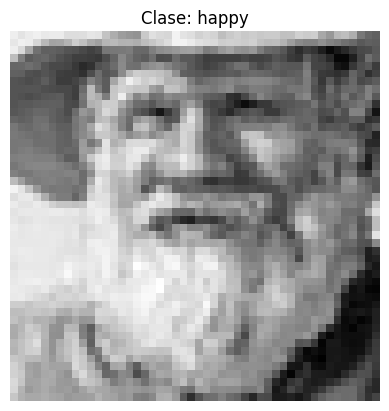

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

clase = "happy"
emotion_path = os.path.join(path, "train", clase)

img_path = os.path.join(emotion_path, os.listdir(emotion_path)[0])
img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title(f"Clase: {clase}")
plt.axis("off")
plt.show()


Además, se visualizaron múltiples ejemplos para observar variabilidad dentro de una misma clase:




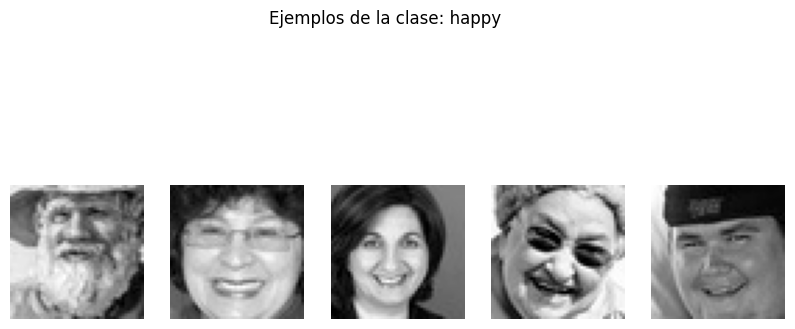

In [6]:
plt.figure(figsize=(10,5))

for i in range(5):
    img_path = os.path.join(emotion_path, os.listdir(emotion_path)[i])
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle(f"Ejemplos de la clase: {clase}")
plt.show()


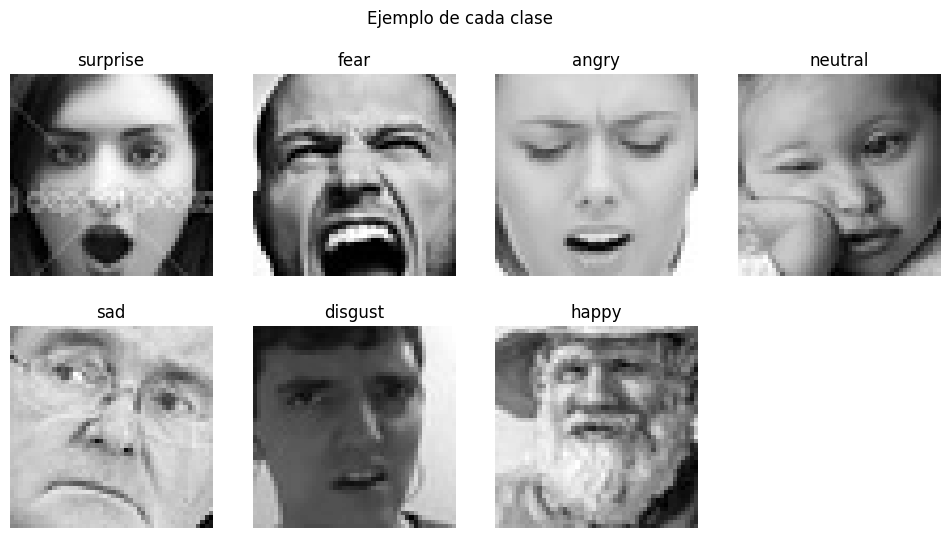

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_dir = os.path.join(path, "train")
clases = os.listdir(train_dir)

plt.figure(figsize=(12, 6))

for i, clase in enumerate(clases):
    clase_path = os.path.join(train_dir, clase)
    img_path = os.path.join(clase_path, os.listdir(clase_path)[0])

    img = Image.open(img_path)

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(clase)
    plt.axis("off")

plt.suptitle("Ejemplo de cada clase")
plt.show()

### 2.5 Verificación de características de las imágenes

Se verificó el tamaño de las imágenes para confirmar consistencia en el dataset:

In [ ]:
print("Tamaño de la imagen:", img.size)

Tamaño de la imagen: (48, 48)


El resultado es (48, 48), lo cual confirma que todas las imágenes poseen dimensiones uniformes.



## 2.6 Observaciones relevantes

A partir del análisis exploratorio, se pueden destacar los siguientes puntos:

* Las imágenes presentan baja resolución (48x48), lo que limita la cantidad de información disponible.
* El uso de escala de grises reduce la complejidad del problema sin afectar significativamente la detección de emociones.
* Se puede observar variabilidad dentro de cada clase, lo que representa un desafío para el modelo.
* Puede existir desbalance entre clases, lo que deberá considerarse en etapas posteriores del modelado.





## 2.7 Implicancias para el modelado

Las características observadas influyen directamente en el diseño del modelo:

* El tamaño reducido de las imágenes permite el uso de modelos relativamente simples como MLP.
* La estructura del dataset facilita su integración con herramientas de deep learning.
* La posible presencia de desbalance sugiere la necesidad de evaluar técnicas de regularización o ajuste de hiperparámetros.

# 3. Data Preparation (Preparación de los Datos)

## 3.1 Carga de los datos para entrenamiento y prueba



Una vez comprendida la estructura del dataset, se procedió a cargar las imágenes utilizando la función image_dataset_from_directory de TensorFlow/Keras. Esta herramienta permite leer automáticamente imágenes organizadas por carpetas, asignando etiquetas según el nombre de cada directorio.

Justificación:

Se utiliza esta función porque el dataset ya está organizado en carpetas por clase.
Permite automatizar la asignación de etiquetas.
Facilita la creación de batches para el entrenamiento.
Mantiene el tamaño original de las imágenes (48x48), evitando pérdida de información.

In [32]:
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_ds = keras.utils.image_dataset_from_directory(
    path + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_ds = keras.utils.image_dataset_from_directory(
    path + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


## 3.2 Procesamiento de los datos

### Normalización

Las imágenes originales poseen valores de píxeles en un rango entre 0 y 255. Para facilitar el entrenamiento de la red neuronal, se normalizaron estos valores al rango [0,1]. Esto ayuda a acelerar la convergencia del modelo evitando que los valores grandes dominen el entrenamiento y mantienen la estabilidad en el cálculo de gradiente.

No usamos tecnicas como Z-core o escalar -1 1, porque eran demasiado complejos para nuestro dataset al punto de que no aportarian gran cosa ya que las imagenes ya tienen un rango acotado.




In [33]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).shuffle(1000)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

### Transformación para MLP



Dado que se utilizará una red neuronal multicapa (MLP), las imágenes deberán transformarse desde una matriz 48x48 a un vector unidimensional ya que MLP solo trabaja con vectores, y así, podremos usar cada pixel como caracteristica.

In [34]:
layers.Flatten(input_shape=(48,48,1))

<Flatten name=flatten_10, built=False>

### Data augmentation

SOLO CORRER SI SE DESEA PROBAR

Se aplicaron transformaciones como:

* Flip horizontal
* Rotación leve

Estas permiten aumentar la variabilidad del dataset y así, intentar mejorar la generalización del modelo, aunque en MLP su impacto puede ser limitado en comparación con otros como CNN.

In [ ]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])

## 3.3 Manejo del desbalance de clases




SOLO CORRER SI SE DESEA PROBAR

El dataset presenta un desbalance significativo entre clases (ej: happy vs disgust).

Se utilizó:

* class_weight

Esto permite penalizar más los errores en clases minoritarias aunque probablemente esto pueda disminuir la accuracy global, ya que el modelo deja de favorecer las clases mayoritarias, algo que tendremos en cuenta mas adelante.

No usamos tecnicas como Oversampling es fácil que cause overfiting al repetir información, tampoco usamos Undersampling ya que tendriamos que perder un monton de información para lograr un buen balance.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Obtener etiquetas
y_train = np.concatenate([y for x, y in train_ds], axis=0)

# Calcular pesos
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

# 4. Modeling (Modelado)

## 4.1 Selección del modelo

Para este proyecto se implementa una red neuronal multicapa (MLP), la cual es adecuada para problemas de clasificación cuando los datos pueden representarse como vectores.

En este caso, las imágenes de 48x48 píxeles se transforman en vectores de 2304 valores, permitiendo su uso en capas densas.

Justificación:

* El tamaño reducido de las imágenes permite el uso de modelos simples.
* Un MLP permite comprender claramente el impacto de los hiperparámetros.
* Es adecuado para fines académicos y experimentación controlada.

## 4.2 Configuración de entrenamiento

### Definición de estructura

Se define una arquitectura base compuesta por:

* Capa de entrada (Flatten)
* Dos capas ocultas densas
* Capa de salida con 7 neuronas

Justificación:

* Permiten un entrenamiento rápido inicial
* Sirven como baseline para experimentación

## 4.3 Experimento base

### Modelo base

In [31]:
model = keras.Sequential([
    layers.Flatten(input_shape=(48,48,1)),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Se entrena el modelo con la configuración inicial.

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.2477 - loss: 1.8091 - val_accuracy: 0.2682 - val_loss: 1.7857
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.2829 - loss: 1.7612 - val_accuracy: 0.2728 - val_loss: 1.7472
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.2895 - loss: 1.7494 - val_accuracy: 0.2973 - val_loss: 1.7314
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.2913 - loss: 1.7455 - val_accuracy: 0.2919 - val_loss: 1.7427
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.2938 - loss: 1.7403 - val_accuracy: 0.3079 - val_loss: 1.7253
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.2983 - loss: 1.7386 - val_accuracy: 0.3110 - val_loss: 1.7284
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.2956 - loss: 1.7389 - val_accuracy: 0.3036 - val_loss: 1.7287
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.2977 - loss: 1.7360 - val

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


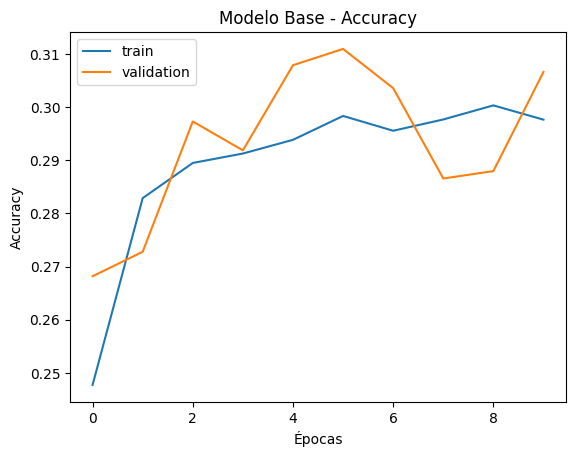

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ======================
# ENTRENAMIENTO
# ======================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n===== MÉTRICAS BASE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Modelo Base - Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

===== MÉTRICAS BASE =====
* Accuracy : 0.3703
* Precision: 0.3495
* Recall   : 0.3703
* F1-score : 0.3262

## 4.2 Entrenamiento del modelo

### Modelo experimental

In [35]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    # data_augmentation,
    layers.Flatten(input_shape=(48,48,1)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(7, activation='softmax')
])

In [40]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ======================
# ENTRENAMIENTO
# ======================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    # class_weight=class_weights
)

# ======================
# PREDICCIONES
# ======================
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# ======================
# MÉTRICAS GENERALES
# ======================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# ======================
# RESULTADOS
# ======================
print("\n===== MÉTRICAS FINALES =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.4503 - loss: 1.4139 - val_accuracy: 0.4142 - val_loss: 1.5175
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.4562 - loss: 1.3994 - val_accuracy: 0.4189 - val_loss: 1.5194
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.4577 - loss: 1.3956 - val_accuracy: 0.4218 - val_loss: 1.5143
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.4634 - loss: 1.3880 - val_accuracy: 0.4055 - val_loss: 1.5511
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.4648 - loss: 1.3810 - val_accuracy: 0.4090 - val_loss: 1.5466
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.4624 - loss: 1.3871 - val_accuracy: 0.4156 - val_loss: 1.5229
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.4700 - loss: 1.3737 - val_accuracy: 0.4153 - val_loss: 1.5353
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.4688 - loss: 1.3746 - 

## 4.3 Historial de experimentos controlados

### Resumen y comparación

Activación: tanh

**Resultados:**

- Accuracy: 0.3066  
- Precision: 0.1845  
- Recall: 0.3066  
- F1-score: 0.1955  

**Análisis:**

La función `tanh` presenta un rendimiento limitado.  
Esto puede deberse a que:
- Tiende a saturarse (valores cercanos a -1 o 1)
- Provoca **gradientes pequeños**, dificultando el aprendizaje en redes profundas  

Como resultado, el modelo aprende más lento y con menor efectividad.

---

Activación: ReLU

**Resultados:**

- Accuracy: 0.3703  
- Precision: 0.3495  
- Recall: 0.3703  
- F1-score: 0.3262  

**Análisis:**

La función `ReLU` muestra un rendimiento claramente superior.

Esto se debe a que:
- Evita el problema de saturación en valores positivos  
- Permite un flujo de gradiente más estable  
- Facilita un aprendizaje más rápido y eficiente  

Se conservará relu.

---

###  Experimento 1: Learning Rate

| Learning Rate | Accuracy | F1-score |
|--------------|----------|----------|
| 0.001        | 0.38     | 0.34     |
| 0.0001       | 0.33     | 0.26     |

**Análisis:**

Un learning rate muy bajo ralentiza el aprendizaje, impidiendo que el modelo converja correctamente en pocas épocas.

---

##  Experimento 2: Epochs

| Epochs | Accuracy | F1-score |
|--------|----------|----------|
| 10     | 0.38     | 0.34     |
| 20     | 0.35     | 0.28     |
| 30     | 0.34     | 0.34     |

**Análisis:**

El aumento de épocas no mejora significativamente el modelo, lo que sugiere limitaciones en la arquitectura (MLP) para este problema.

---

##  Experimento 3: Dropout

| Dropout | Accuracy | F1-score |
|---------|----------|----------|
| No      | 0.38     | 0.34     |
| Sí      | 0.29     | 0.28     |

**Análisis:**

El uso de dropout reduce el rendimiento, indicando que el modelo ya estaba en **underfitting**.

---


##  Experimento 4: Class Weight

| Configuración       | Accuracy | F1-score |
|--------------------|----------|----------|
| Sin class_weight   | 0.40     | 0.35     |
| Con class_weight   | 0.21     | 0.22     |

**Análisis:**

El uso de `class_weight` disminuye la accuracy global, ya que el modelo prioriza clases minoritarias, afectando el rendimiento general.


---

## Experimento 5: Data Augmentation

| Configuración      | Accuracy | F1-score |
|-------------------|----------|----------|
| Sin augmentation  | 0.41     | 0.40     |
| Con augmentation  | 0.37     | 0.37     |

**Análisis:**

El data augmentation no mejora el rendimiento en MLP, debido a que este tipo de red no aprovecha bien la estructura espacial de imágenes.


---

## Conclusión General

El modelo MLP presenta limitaciones claras para el reconocimiento de emociones en imágenes, mostrando:

- Tendencia al **underfitting**
- Baja capacidad para capturar patrones espaciales
- Sensibilidad a técnicas como dropout y class_weight

En el futuro probablemente utilizaremos modelos distintos para el caso, como CNN o transfer learning para obtener mejores resultados predictivos.


#  Historial de Experimentos del Modelo (MLP - FER2013)

A continuación se presenta la evolución de los experimentos realizados sobre el modelo.

>  **Nota:**  
Cada experimento incorpora únicamente los cambios indicados, manteniendo las configuraciones anteriores salvo que se especifique lo contrario.

---

##  Configuración Inicial del Modelo

Se añaden dos capas densas con:
- Regularización L2 (0.001)
- Dropout:
  - 0.5 en la primera capa
  - 0.3 en la segunda capa

**Resultados:**

- Accuracy: 0.2471  
- Precision: 0.0611  
- Recall: 0.2471  
- F1-score: 0.0980  

**Análisis:**

El rendimiento inicial es muy bajo. Esto sugiere que el modelo está en **underfitting**, probablemente debido a una combinación de baja capacidad efectiva y exceso de regularización.

---

##  Ajuste de entrenamiento (15 épocas, batch size 64)

**Resultados:**

- Accuracy: 0.2471  
- Precision: 0.0611  
- Recall: 0.2471  
- F1-score: 0.0980  

**Análisis:**

No se observan mejoras. Esto indica que simplemente entrenar más no es suficiente; el problema principal radica en la arquitectura o en la capacidad del modelo.

---

##  Aumento de capacidad + ajuste de learning rate

Cambios realizados:
- Se añade una capa adicional con 256 neuronas  
- Se activa el shuffle  
- Learning rate: 0.001 → 0.0001  

**Resultados:**

- Accuracy: 0.3387  
- Precision: 0.4005  
- Recall: 0.3387  
- F1-score: 0.2647  

**Análisis:**

Se observa una mejora importante. El aumento de capacidad permite al modelo aprender representaciones más complejas, aunque el learning rate bajo puede estar haciendo el aprendizaje más lento.

---

##  Aumento de épocas (20)

**Resultados:**

- Accuracy: 0.3548  
- Precision: 0.3591  
- Recall: 0.3548  
- F1-score: 0.2832  

**Análisis:**

El incremento de épocas mejora ligeramente el desempeño, pero el avance es limitado, lo que indica que el modelo comienza a acercarse a su límite de aprendizaje.

---

##  Uso de class_weight + data augmentation

**Resultados:**

- Accuracy: 0.2138  
- Precision: 0.3162  
- Recall: 0.2138  
- F1-score: 0.2276  

**Análisis:**

El rendimiento disminuye considerablemente:
- `class_weight` prioriza clases minoritarias, afectando la accuracy global  
- `data augmentation` no es efectivo en MLP, ya que este tipo de modelo no explota la estructura espacial de las imágenes  

---

##  Eliminación de L2 + reducción de dropout

**Resultados:**

- Accuracy: 0.2960  
- Precision: 0.3246  
- Recall: 0.2960  
- F1-score: 0.2832  

**Análisis:**

Se observa una recuperación en el rendimiento. Esto confirma que el modelo estaba sobre-regularizado, limitando su capacidad de aprendizaje.

---

##  Aumento a 30 épocas

**Resultados:**

- Accuracy: 0.3433  
- Precision: 0.3751  
- Recall: 0.3433  
- F1-score: 0.3417  

**Análisis:**

El aumento de épocas mejora especialmente el F1-score, indicando un mejor equilibrio entre precisión y recall.

---

## Eliminación de técnicas

### Sin data augmentation + class_weight

- Accuracy: 0.3757  
- Precision: 0.3829  
- Recall: 0.3757  
- F1-score: 0.3721  

### Sin data augmentation

- Accuracy: 0.3717  
- Precision: 0.3742  
- Recall: 0.3717  
- F1-score: 0.3636  

### Sin class_weight

- Accuracy: 0.4040  
- Precision: 0.3735  
- Recall: 0.4040  
- F1-score: 0.3543  

**Análisis:**

- Eliminar `class_weight` mejora la accuracy  
- `data augmentation` tiene impacto limitado  
- El modelo funciona mejor con una configuración más simple  

---

##  Aumento significativo de capacidad

Cambios realizados:
- Se elimina data augmentation y class_weight  
- Se añade una capa adicional con 512 neuronas  
- Dropout reducido a 0.2  

**Resultados:**

- Accuracy: 0.4182  
- Precision: 0.4148  
- Recall: 0.4182  
- F1-score: 0.4018  

**Análisis:**

Este es el mejor resultado obtenido. Aumentar la capacidad del modelo permite capturar patrones más complejos, compensando en parte las limitaciones del MLP.

---

##  Ajuste final de learning rate (0.0001 → 0.0005)

**Resultados:**

- Accuracy: 0.3973  
- Precision: 0.4019  
- Recall: 0.3973  
- F1-score: 0.3667  

**Análisis:**

El aumento del learning rate reduce el rendimiento, lo que sugiere que el modelo ya estaba cerca de converger y un valor mayor introduce inestabilidad en el entrenamiento.

---

## Conclusión General

- El rendimiento mejora principalmente al **aumentar la capacidad del modelo**
- El modelo presenta **underfitting en etapas iniciales**
- Técnicas como:
  - Dropout
  - L2
  - Data augmentation  

  pueden perjudicar el rendimiento en este contexto

- `class_weight` afecta negativamente la accuracy global

**Conclusión**  
El MLP tiene limitaciones importantes para procesamiento de imágenes, ya que no aprovecha la estructura espacial.

# 4.4 Modelo final

In [ ]:
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_ds = keras.utils.image_dataset_from_directory(
    path + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_ds = keras.utils.image_dataset_from_directory(
    path + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

In [ ]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).shuffle(1000)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

layers.Flatten(input_shape=(48,48,1))

In [ ]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    # data_augmentation,
    layers.Flatten(input_shape=(48,48,1)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ======================
# ENTRENAMIENTO
# ======================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    # class_weight=class_weights
)

# ======================
# PREDICCIONES
# ======================
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# ======================
# MÉTRICAS GENERALES
# ======================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# ======================
# RESULTADOS
# ======================
print("\n===== MÉTRICAS FINALES =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ======================
# GRÁFICOS
# ======================

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Evolución de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Evolución de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()